In [2]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

current_dir = Path.cwd()
while not (current_dir / "src").exists() and current_dir != current_dir.parent:
    current_dir = current_dir.parent
SRC_DIR = current_dir / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataset import load_dataset
from classification.voting_ensemble_classifier import VotingEnsembleClassifier
from score_PHM import get_classification_score, get_challange_score

plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [3]:
TRAIN_PATH_FULL = "../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT = "../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH="../../../output/voting_classifier/"
OUTPUT_PATH_PR="../../../output/polynomial_regression/model_target/"
OUTPUT_PATH_RF= "../../../output/random_forest_regressor/model_target/"
OUTPUT_PATH_GPR= "../../../output/GPR/model_target/"
MODEL_PATH = "voting.pkl"
TARGET_COL = "faulty"
FEUTURE=["trq_margin","oat","pa","np_ng_ratio","ias","mgt"]
FEUTURE_PREDICT=["trq_margin_pred","oat","pa","np_ng_ratio","ias","mgt"]

In [ ]:
train_df=load_dataset(TRAIN_PATH_SPLIT)
test_df=load_dataset(TEST_PATH_SPLIT)
test_df_predict_PR=load_dataset(OUTPUT_PATH_PR+"pred_margin_test.csv")
test_df_predict_RF=load_dataset(OUTPUT_PATH_RF+"pred_margin_test.csv")
test_df_predict_GPR=load_dataset(OUTPUT_PATH_GPR+"pred_margin_test.csv")

X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test= test_df[TARGET_COL].values

X_test_predict_PR = test_df_predict_PR[FEUTURE_PREDICT].values
y_test_predict_PR= test_df_predict_PR[TARGET_COL].values

X_test_predict_RF = test_df_predict_RF[FEUTURE_PREDICT].values
y_test_predict_RF= test_df_predict_RF[TARGET_COL].values


X_test_predict_GPR = test_df_predict_GPR[FEUTURE_PREDICT].values
y_test_predict_GPR= test_df_predict_GPR[TARGET_COL].values

In [6]:
voting_model = VotingEnsembleClassifier()

if os.path.exists(OUTPUT_PATH + MODEL_PATH):
    voting_model = joblib.load(OUTPUT_PATH + MODEL_PATH)
    print("Modello caricato da disco.")
else:
    voting_model.fit(X_train, y_train)
    os.makedirs(OUTPUT_PATH, exist_ok=True)  # crea la cartella prima di salvare
    joblib.dump(voting_model, OUTPUT_PATH + MODEL_PATH)
    print(f"Modello addestrato e salvato in: {OUTPUT_PATH + MODEL_PATH}")


Modello caricato da disco.


In [7]:
voting_model.get_weights()

array([0.48102404, 0.22065403, 0.29832193])


ENSEMBLE (VotingClassifier)


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9991
F1 macro: 0.9990

Confusion Matrix:
[[66440    41]
 [   61 44852]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



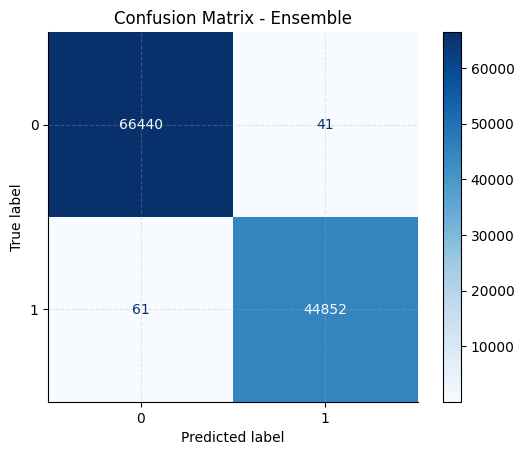


BASE MODEL: RF
Accuracy: 0.9995
F1 macro: 0.9995

Confusion Matrix:
[[66464    17]
 [   40 44873]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



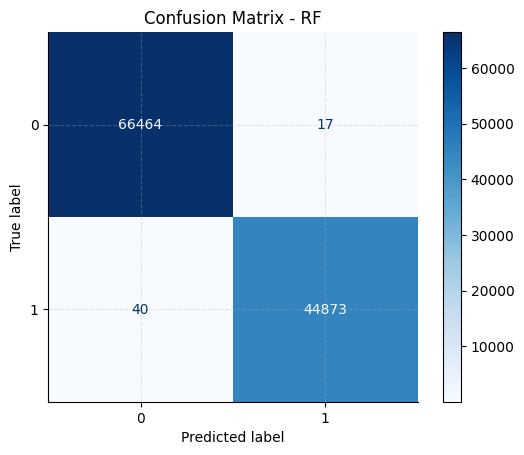


BASE MODEL: XGB
Accuracy: 0.9973
F1 macro: 0.9971

Confusion Matrix:
[[66340   141]
 [  165 44748]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



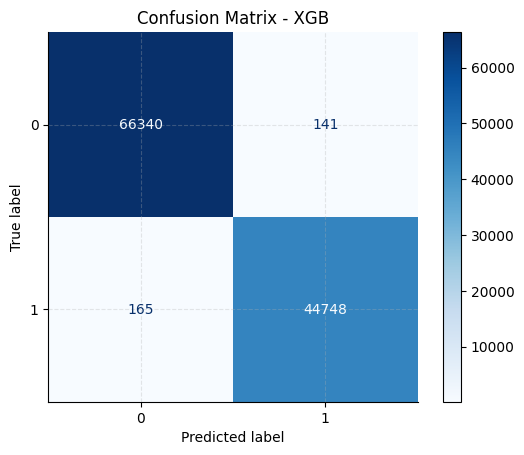


BASE MODEL: LGBM


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9982
F1 macro: 0.9982

Confusion Matrix:
[[66395    86]
 [  111 44802]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



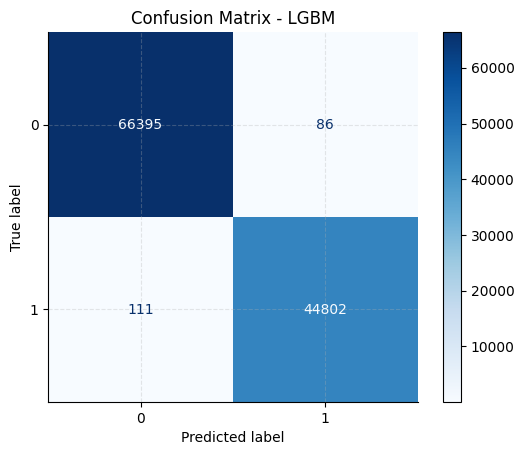

{'ensemble': {'accuracy': 0.9990843312925293,
  'f1_macro': 0.9990485986628928,
  'confusion_matrix': array([[66440,    41],
         [   61, 44852]])},
 'base_models': {'rf': {'accuracy': 0.9994883027811192,
   'f1_macro': 0.9994683287800592,
   'confusion_matrix': array([[66464,    17],
          [   40, 44873]])},
  'xgb': {'accuracy': 0.9972529938775877,
   'f1_macro': 0.9971457547090568,
   'confusion_matrix': array([[66340,   141],
          [  165, 44748]])},
  'lgbm': {'accuracy': 0.9982315025943946,
   'f1_macro': 0.9981624563542177,
   'confusion_matrix': array([[66395,    86],
          [  111, 44802]])}}}

In [8]:
voting_model.evaluate(X_test, y_test)

In [9]:
idx=27568
test_X_row = test_df.loc[[idx], FEUTURE]
test_y_true = test_df.loc[idx, TARGET_COL]
y_pred = voting_model.predict(test_X_row)
test_X_score=voting_model.evaluate_phm_score(test_X_row,test_y_true)
print("True class:", test_y_true)
print("Pred class:", y_pred)


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


PHM score Ensemble (mean): 0.9771
PHM score RF (mean): 1.0000
PHM score XGB (mean): 0.9324
PHM score LGBM (mean): 0.9733
True class: 1
Pred class: [1]


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [10]:
voting_model.evaluate_phm_score(X_test,y_test)

c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PHM score Ensemble (mean): 0.9929
PHM score RF (mean): 0.9952
PHM score XGB (mean): 0.9877


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PHM score LGBM (mean): 0.9909


{'ensemble_mean': 0.9928861215686233,
 'ensemble_scores': [0.9999404178169347,
  0.9995412710466756,
  0.9989335079248765,
  0.9994682372933217,
  0.9999069457190229,
  0.9999186063249399,
  0.9956278899928672,
  0.9999732554935788,
  0.9975002212087445,
  0.9987296202907814,
  0.9998821790423518,
  0.9893612562421477,
  0.9997036752605892,
  0.9995999372632398,
  0.9999218832960977,
  0.9999560861177504,
  0.992722211774345,
  0.9999929062359166,
  0.9762184524453934,
  0.999860167865704,
  0.9981144740415717,
  0.9999998894726312,
  0.9832052946911283,
  0.99999914109495,
  0.9996744344985506,
  0.9999994888512732,
  0.999999152177996,
  0.9999500445070492,
  0.9999991392246765,
  0.9972433678197754,
  0.9999950509809725,
  0.9999966881615734,
  0.9999734750695803,
  0.9999814088641614,
  0.8705814898013152,
  0.9999138353833346,
  0.9981680203798098,
  0.9999768718743406,
  0.9999834208847365,
  0.9999882794445085,
  0.999998731983732,
  0.9999997356493668,
  0.9515842911349635,
  0

In [ ]:
voting_model.evaluate(X_test_predict_PR,y_test_predict_PR)


ENSEMBLE (VotingClassifier)


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9990
F1 macro: 0.9990

Confusion Matrix:
[[66443    38]
 [   70 44843]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



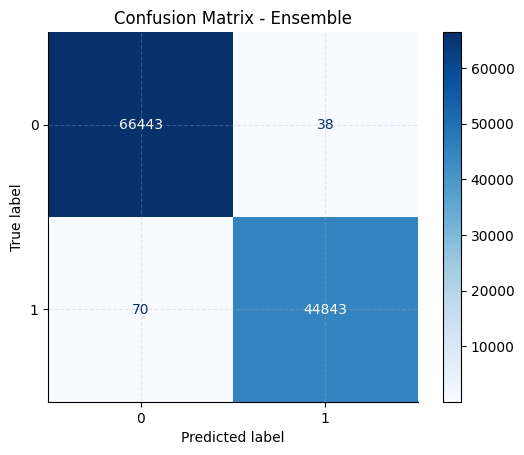


BASE MODEL: RF
Accuracy: 0.9993
F1 macro: 0.9993

Confusion Matrix:
[[66463    18]
 [   56 44857]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



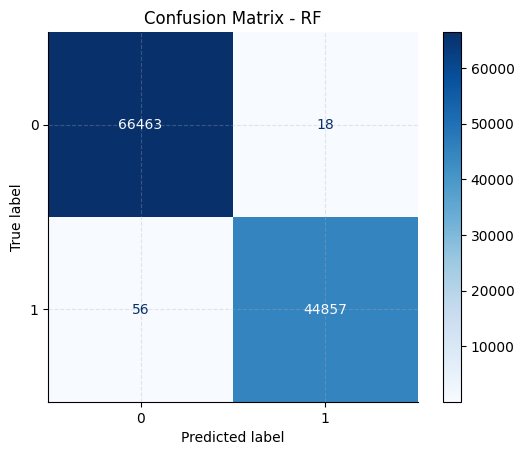


BASE MODEL: XGB
Accuracy: 0.9972
F1 macro: 0.9971

Confusion Matrix:
[[66343   138]
 [  170 44743]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



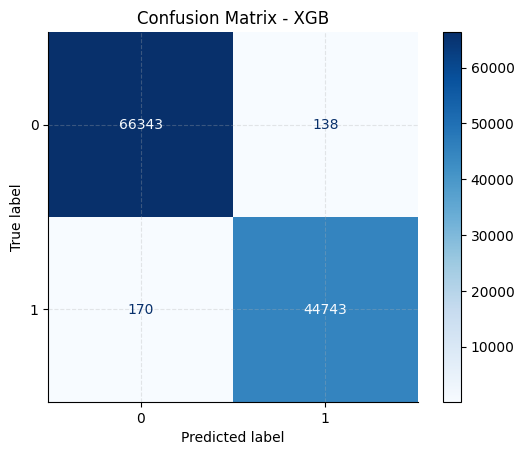


BASE MODEL: LGBM


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9982
F1 macro: 0.9981

Confusion Matrix:
[[66397    84]
 [  116 44797]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



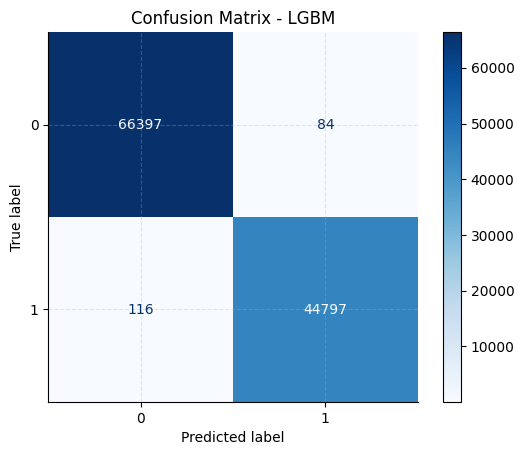

{'ensemble': {'accuracy': 0.9990304684273839,
  'f1_macro': 0.9989925901611596,
  'confusion_matrix': array([[66443,    38],
         [   70, 44843]])},
 'base_models': {'rf': {'accuracy': 0.9993356913298741,
   'f1_macro': 0.999309722718611,
   'confusion_matrix': array([[66463,    18],
          [   56, 44857]])},
  'xgb': {'accuracy': 0.9972350395892059,
   'f1_macro': 0.9971270163855294,
   'confusion_matrix': array([[66343,   138],
          [  170, 44743]])},
  'lgbm': {'accuracy': 0.998204571161822,
   'f1_macro': 0.9981344262243698,
   'confusion_matrix': array([[66397,    84],
          [  116, 44797]])}}}

In [ ]:
#voting_model.evaluate(X_test_predict_RF,y_test_predict_RF)


ENSEMBLE (VotingClassifier)


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9991
F1 macro: 0.9990

Confusion Matrix:
[[66439    42]
 [   62 44851]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



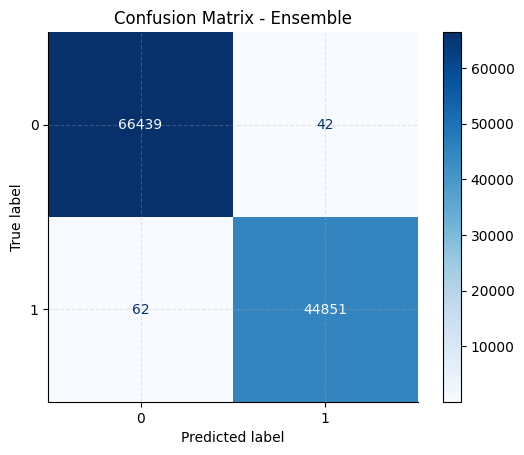


BASE MODEL: RF
Accuracy: 0.9995
F1 macro: 0.9995

Confusion Matrix:
[[66464    17]
 [   40 44873]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



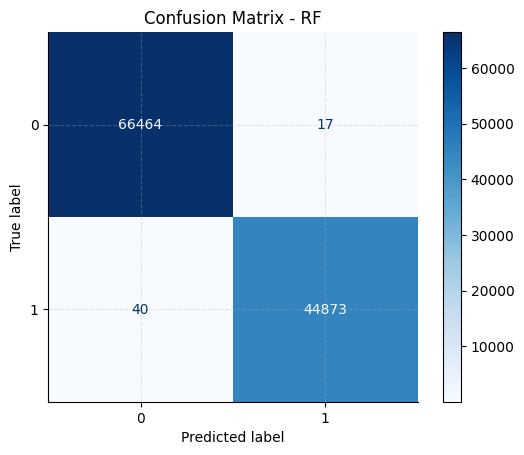


BASE MODEL: XGB
Accuracy: 0.9973
F1 macro: 0.9972

Confusion Matrix:
[[66342   139]
 [  166 44747]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



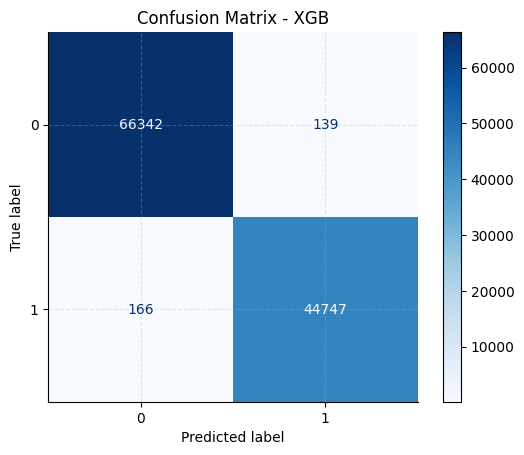


BASE MODEL: LGBM


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9982
F1 macro: 0.9982

Confusion Matrix:
[[66396    85]
 [  113 44800]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



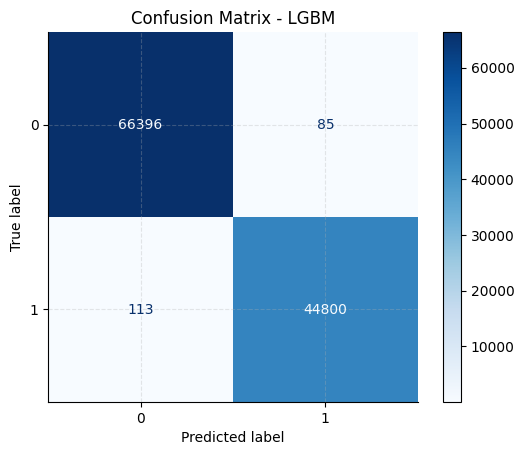

{'ensemble': {'accuracy': 0.9990663770041475,
  'f1_macro': 0.9990299437347143,
  'confusion_matrix': array([[66439,    42],
         [   62, 44851]])},
 'base_models': {'rf': {'accuracy': 0.9994883027811192,
   'f1_macro': 0.9994683287800592,
   'confusion_matrix': array([[66464,    17],
          [   40, 44873]])},
  'xgb': {'accuracy': 0.9972619710217786,
   'f1_macro': 0.9971550514437222,
   'confusion_matrix': array([[66342,   139],
          [  166, 44747]])},
  'lgbm': {'accuracy': 0.9982225254502037,
   'f1_macro': 0.9981531086839129,
   'confusion_matrix': array([[66396,    85],
          [  113, 44800]])}}}

In [12]:
voting_model.evaluate(X_test_predict_GPR,y_test_predict_GPR)

In [ ]:
# Submission finale: aggiunge class e class_conf al JSON parziale del GPR

partial_path = OUTPUT_PATH_GPR + "submission_partial.json"
with open(partial_path, "r") as f:
    submission = json.load(f)

print(f"JSON parziale caricato: {len(submission)} campioni")

# Predizione sul margin predetto dal GPR (consistente con la pipeline)
class_preds  = voting_model.predict(X_test_predict_GPR)
class_probas = voting_model.predict_proba(X_test_predict_GPR)  # shape: (n, 2)

# Confidenza = probabilita della classe predetta
class_confs = [
    float(class_probas[i][class_preds[i]])
    for i in range(len(class_preds))
]

# Aggiunta class e class_conf al JSON parziale
for i in range(len(class_preds)):
    submission[str(i)]["class"]      = int(class_preds[i])
    submission[str(i)]["class_conf"] = round(class_confs[i], 6)

# Salvataggio file finale .jso come richiede PHM
os.makedirs(OUTPUT_PATH, exist_ok=True)
output_path = OUTPUT_PATH + "submission.json"
with open(output_path, "w") as f:
    json.dump(submission, f, indent=4)

print(f"Submission finale salvata in: {output_path}")

# Anteprima prime 3 entry
for k in list(submission.keys())[:3]:
    print(f"{k}: {submission[k]}")


JSON parziale caricato: 111394 campioni


c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\giada\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Submission finale salvata in: ../../../output/voting_classifier/submission.jso
0: {'pdf_type': 'norm', 'pdf_args': {'loc': 12.612663379544195, 'scale': 0.14324035011629688}, 'class': 0, 'class_conf': 0.99994}
1: {'pdf_type': 'norm', 'pdf_args': {'loc': 2.4215611263939385, 'scale': 0.0811299060646553}, 'class': 0, 'class_conf': 0.999541}
2: {'pdf_type': 'norm', 'pdf_args': {'loc': -7.048854371707722, 'scale': 0.06454359797389372}, 'class': 1, 'class_conf': 0.998934}
